# Comparison of 21CMFAST outputs and preion predictions

In [ ]:
import time
import matplotlib.pyplot as plt
from matplotlib import rc, colors, cm
import numpy as np
from astropy import units, constants
from astropy.cosmology import Planck18 as cos
# import healpy as hp
import os, sys
import h5py
from scipy.interpolate import RegularGridInterpolator, interp1d
from tqdm import tqdm
from scipy import optimize

In [2]:
sys.path.insert(0, '../forecast_autos/')
sys.path.insert(0, '../')

In [3]:
from theory import Pee_model
from utils import *
from utils_tau import tau_noise
from parameters import nu21_ref, telescope_specs

In [4]:
rc("font", **{"family": "serif", "serif": ["times new roman"], "size": 18})
# rc("text", usetex=True)
rc("axes", linewidth=1.5)
props = dict(boxstyle="round", facecolor="white", alpha=0.8)


In [5]:
def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=100):
    new_cmap = colors.LinearSegmentedColormap.from_list(
        'trunc({n},{a:.2f},{b:.2f})'.format(n=cmap.name, a=minval, b=maxval),
        cmap(np.linspace(minval, maxval, n)))
    return new_cmap

In [6]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

In [7]:
CL = 68
percentile1 = (100.-CL)/2.
percentile2 = CL+(100.-CL)/2.

In [8]:
ells_plot = np.logspace(0, 4, 100)

In [9]:
fl = h5py.File('/data/cluster/agorce/big_lightcone_21cmfast.h5', "r")

z_nodes = fl['node_redshifts'][:]
glob_xHII = np.array(1. - fl['global_quantities']['xH_box'][:])

lc_dists = fl['distances'][:][::-1]
n_lc = len(lc_dists)
zz = np.loadtxt('big_lightcone_21cmfast_zvalues.txt')

fl.close()

In [127]:
lc_xHII, lc_xHII_wavg = np.loadtxt('data_big_lightcone/big_lightcone_reion_history.txt', usecols=(1, 2), unpack=True)

Define the `preion` model

In [157]:
theta_true = [7.5, 2.5, 4.3, 0.065]
bdH_params = [0.74288, 0.68448967, 5.21604423]

The `Pee_model` class allows you to compute the kSZ angular power spectrum, the optical depth power spectrum, and the 21cm power spectrum, all following a consistent reionsation model, based on the electron power spectrum parameterisation introduced in Gorce et. al 2020.

In [158]:
model = Pee_model(
    h=cos.h,
    Ob_0=cos.Ob0,
    Om_0=cos.Om0,
    asym_h_reion=True,
    zre_h=theta_true[0],
    dz_h=theta_true[1],
    alpha0=theta_true[2],
    kappa=theta_true[3],
    kf=bdH_params[0], 
    g=bdH_params[1], 
    alpha=bdH_params[2],
    z_early=15.,
    helium=False,
    helium2=False,
    verbose=True, 
    run_camb=False,
    # use_ksz_emulator='RF',
)

zre_h = 7.5, zend = 5.0
Late-time ionisation fraction: 1.00
tau = 0.0528


## Reionisation history

In [159]:
print(model.tau)

0.05275766422046334


5.0 7.5


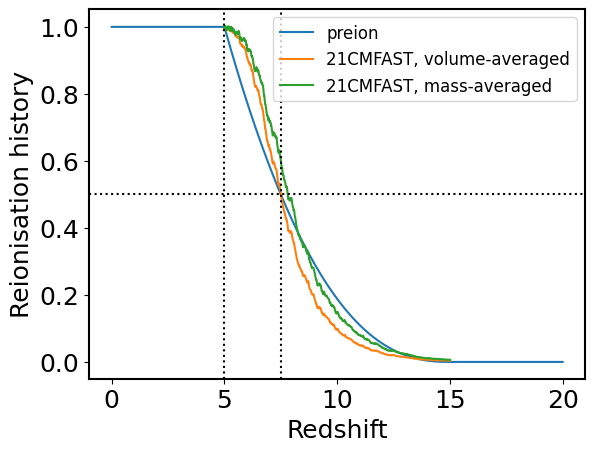

In [160]:
z = np.linspace(0, 20, 300)
print(model.zend_h, model.zre_h)

plt.figure()
plt.plot(z, model.xe(z), label='preion')
plt.plot(zz, lc_xHII, label='21CMFAST, volume-averaged')
plt.plot(zz, lc_xHII_wavg, label='21CMFAST, mass-averaged')
plt.xlabel(r'Redshift')
plt.ylabel(r'Reionisation history')
plt.legend(fontsize=12)
# plt.xlim(5, 15)
plt.axvline(model.zend_h, color='k', ls=':')
plt.axhline(.5, color='k', ls=':')
plt.axvline(model.zre_h, color='k', ls=':')

## $\tau$ power spectrum

In [161]:
l, cl_tau_tau, el_tau_tau = np.loadtxt('data_big_lightcone/big_lightcone_cltautau.txt', usecols=(0,1,2), unpack=True)
cl_tau_tau_no_dens_corr, el_tau_tau_no_dens_corr = np.loadtxt('data_big_lightcone/big_lightcone_cltautau.txt', usecols=(3,4), unpack=True)
cl_tau_tau_from_pee = np.loadtxt('data_big_lightcone/big_lightcone_cltautau.txt', usecols=(5), unpack=True)

In [162]:
ells_tau = np.copy(l)

To compute the $\tau-\tau$ power spectrum, use the `get_tau` method. 
The following will output the tau power on a range of multipoles `ells` as $\mathcal{D}_\ell = T_\mathrm{CMB} \ell (\ell + 1) C_\ell / 2 \pi$.

/data/glx-calcul3/data1/agorce/cross-correlations/cross-correlations/With_Pee/with_py21cmfast/../theory.py:1109: UserWarning: Re-running CAMB...
  warnings.warn('Re-running CAMB...')


Running CAMB...
Computation took 11.7 seconds.


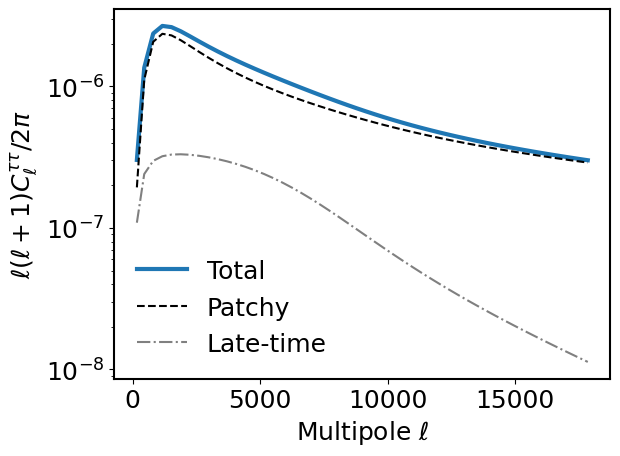

In [163]:
t0 = time.time()
tau_ps = model.get_tau(ells=ells_tau, signal='both', Dells=True)
t1 = time.time()
print(f'Computation took {t1-t0:.1f} seconds.')

plt.figure()
plt.semilogy(ells_tau, np.sum(tau_ps, axis=1), label='Total', lw=3.)
plt.plot(ells_tau, tau_ps[:, 0], label='Patchy', ls='--', color='k')
plt.plot(ells_tau, tau_ps[:, 1], label='Late-time', ls='-.', color='grey')
plt.xlabel(r'Multipole $\ell$')
plt.ylabel(r'$\ell(\ell+1)C_\ell^{\tau\tau}/2\pi$')
# plt.ylim(1e-5, 1e-2)
plt.legend(frameon=False)
# plt.xlim(0, 3000)

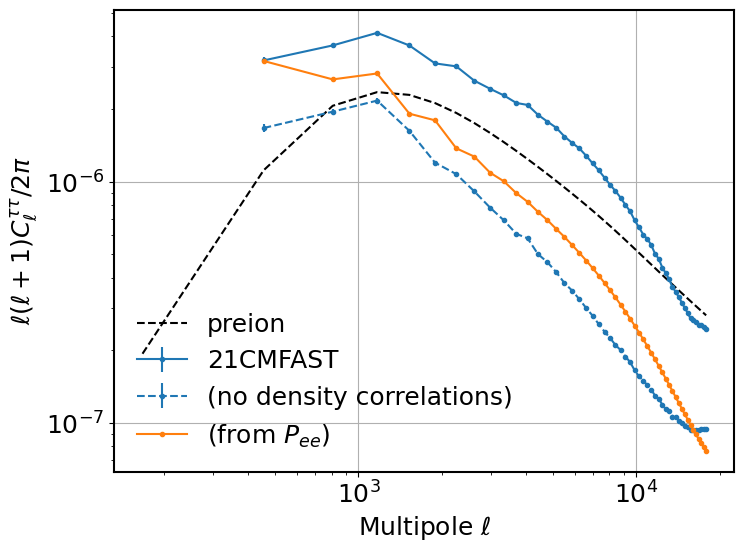

In [167]:
tau_ps_fit = model.get_tau(ells=ells_tau, zmin=zz.min(), zmax=zz.max(), Dells=True)[:, 0]

plt.figure(figsize=(8, 6))
plt.loglog(ells_tau, tau_ps_fit, label='preion', ls='--', color='k')
m = (cl_tau_tau != 0.) & (l * (l+1.) * cl_tau_tau / 2./np.pi < 1e-5) & (l * (l+1.) * cl_tau_tau_no_dens_corr / 2./np.pi < 1e-5)
plt.errorbar(
        l[m], l[m] * (l[m]+1.) * cl_tau_tau[m] / 2. / np.pi,
        yerr=l[m] * (l[m]+1.) * el_tau_tau[m] / 2./np.pi,
        marker='.', color='C0', label='21CMFAST')
plt.errorbar(
        l[m], l[m] * (l[m]+1.) * cl_tau_tau_no_dens_corr[m] / 2. / np.pi,
        yerr=l[m] * (l[m]+1.) * el_tau_tau_no_dens_corr[m] / 2./np.pi,
        marker='.', color='C0', label='(no density correlations)', ls='--')
plt.errorbar(
        l[m], l[m] * (l[m]+1.) * cl_tau_tau_from_pee[m] / 2. / np.pi,
        # yerr=l[m] * (l[m]+1.) * el_tau_tau_fr[m] / 2./np.pi,
        marker='.', color='C1', label=r'(from $P_{ee}$)')
plt.xlabel(r'Multipole $\ell$')
plt.ylabel(r'$\ell(\ell+1)C_\ell^{\tau\tau}/2\pi$')
# plt.ylim(1e-5, 1e-2)
plt.grid()
plt.legend(frameon=False)
# plt.xlim(0, 3000)

`preion` overestimates the $\tau\tau$ signal on small scales as there is the same mismatch at the electron PS level (see below). The missing power on larger scales could be due either to also a mismatch at the $P_{ee}$ level or to the Limber approximation (difference between orange and blue solid lines).

In [112]:
cl_tau_tau/cl_tau_tau_no_dens_corr

array([1.82948958e-03, 1.90694473e+00, 1.88259420e+00, 1.90987773e+00,
       2.25958626e+00, 2.58092065e+00, 2.79881556e+00, 2.87786506e+00,
       3.10995378e+00, 3.29765533e+00, 3.49100600e+00, 3.57389045e+00,
       3.78342117e+00, 3.82857631e+00, 3.97328789e+00, 4.05678577e+00,
       4.09703177e+00, 4.22359797e+00, 4.28037022e+00, 4.28791694e+00,
       4.34832629e+00, 4.35219929e+00, 4.31981662e+00, 4.35463524e+00,
       4.28419225e+00, 4.25445649e+00, 4.22296819e+00, 4.18862721e+00,
       4.14991029e+00, 4.03290030e+00, 4.03903655e+00, 3.98259765e+00,
       3.87373116e+00, 3.80354644e+00, 3.70535161e+00, 3.66694788e+00,
       3.52644261e+00, 3.44084489e+00, 3.32325033e+00, 3.25664431e+00,
       3.15733571e+00, 3.10234350e+00, 2.97916617e+00, 2.90210102e+00,
       2.86230280e+00, 2.79421562e+00, 2.73060982e+00, 2.69731761e+00,
       2.62588867e+00, 2.58661383e+00])

In [ ]:
cl_tau_tau/cl_tau_tau_from_pee

## kSZ power spectrum

In [120]:
_, cl_ksz, el_ksz = np.loadtxt('data_big_lightcone/big_lightcone_clksz.txt', usecols=(0,1,2), unpack=True)
cl_ksz_no_dens_corr, el_ksz_no_dens_corr = np.loadtxt('data_big_lightcone/big_lightcone_clksz.txt', usecols=(3,4), unpack=True)

In [ ]:
t0 = time.time()
ksz_ps = model.get_ksz(ells=ells_tau, signal='both', Dells=True)
t1 = time.time()
print(f'Computation took {t1-t0:.1f} seconds.')

Computation took 716.1 seconds.


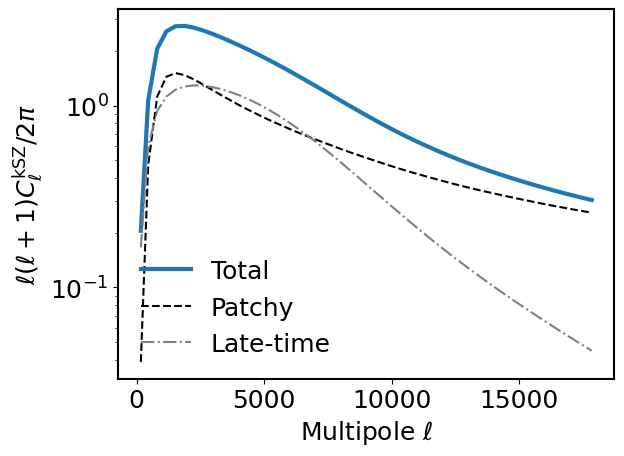

In [122]:
plt.figure()
plt.semilogy(ells_tau, np.sum(ksz_ps, axis=1), label='Total', lw=3.)
plt.plot(ells_tau, ksz_ps[:, 0], label='Patchy', ls='--', color='k')
plt.plot(ells_tau, ksz_ps[:, 1], label='Late-time', ls='-.', color='grey')
plt.xlabel(r'Multipole $\ell$')
plt.ylabel(r'$\ell(\ell+1)C_\ell^\mathrm{kSZ}/2\pi$')
# plt.ylim(1e-5, 1e-2)
plt.legend(frameon=False)
# plt.xlim(0, 3000)

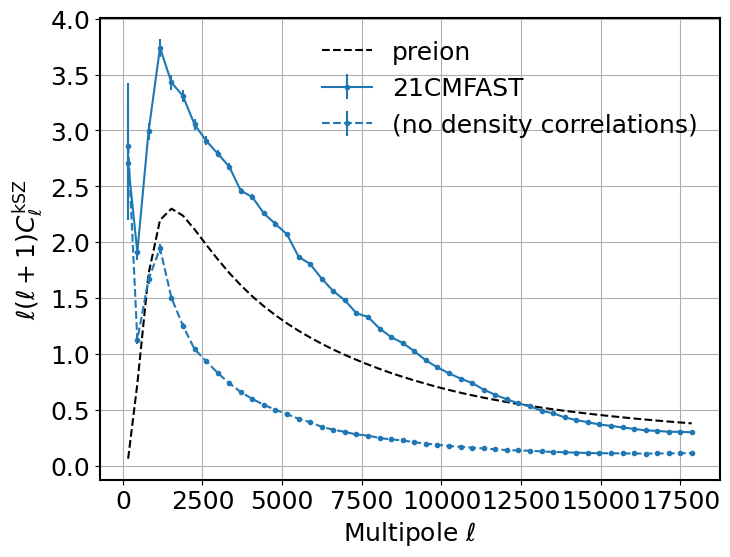

In [168]:
ksz_ps_fit = model.get_ksz(ells=ells_tau, zmin=zz.min(), zmax=zz.max(), Dells=True)[:, 0]


plt.figure(figsize=(8,6))
plt.plot(ells_tau, ksz_ps_fit, label='preion', ls='--', color='k')
m = (cl_ksz != 0.) & (l * (l+1.) * cl_ksz / 2./np.pi < 5.)
plt.errorbar(
        l[m], l[m] * (l[m]+1.) * cl_ksz[m] / 2. / np.pi,
        yerr=l[m] * (l[m]+1.) * el_ksz[m] / 2./np.pi,
        marker='.', color='C0', label='21CMFAST')
plt.errorbar(
        l[m], l[m] * (l[m]+1.) * cl_ksz_no_dens_corr[m] / 2. / np.pi,
        yerr=l[m] * (l[m]+1.) * el_ksz_no_dens_corr[m] / 2./np.pi,
        marker='.', color='C0', label='(no density correlations)', ls='--')
plt.xlabel(r'Multipole $\ell$')
plt.ylabel(r'$\ell(\ell+1)C_\ell^\mathrm{kSZ}}/2\pi$')
# plt.ylim(1e-5, 1e-2)
plt.grid()
plt.legend(frameon=False)
# plt.xlim(0, 3000)

`preion` overestimates the kSZ signal on small scales as their is the same mismatch at the electron PS level (see below). The missing power on larger scales could be due either to also a mismatch at the $P_{ee}$ level or to the Limber approximation.

## Electron power spectrum

In [22]:
cmap = colormaps['viridis']
norm = colors.LogNorm(vmin=5e-4, vmax=1.)

The electron power spectrum from the 21CMFAST lightcone has been computed over redshift slides, such that it is a 2D power spectrum. To recover the 3D power spectrum $P_{ee}(k,z)$, in Mpc$^3$, at the basis of our model, we need to rescale the power spectrum:
\begin{equation}
P_{3D}(k,z) = \frac{\pi}{k} P_{2D}(k,z)
\end{equation}

This equation can be found by identifying the dimensionless power spectrum: $\Delta^2(k,z)\equiv \frac{k^3}{2\pi^2}P_{3D}(k,z)\equiv\frac{k^2}{2\pi}P_{2D}(k,z)$.

In [113]:
pkee = np.loadtxt('data_big_lightcone/big_lightcone_pkee.txt')
ke = pkee[:, 0]
pkee = np.delete(pkee, 0, axis=1).T * np.pi/ke

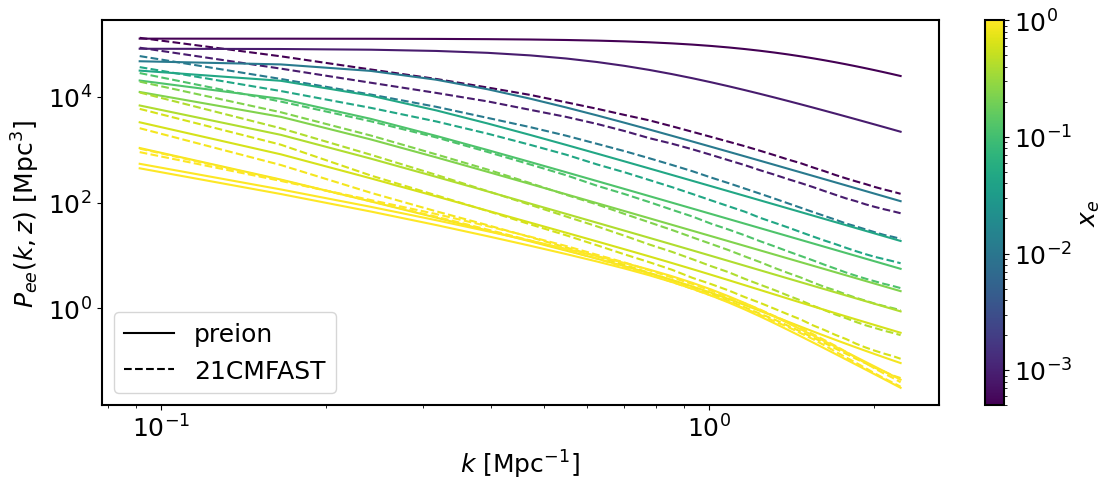

In [119]:
fig, ax = plt.subplots(figsize=(12, 5))
for iz in np.arange(0, z_nodes.size, 5):
    ax.loglog(ke, pkee[iz], color=cmap(norm(model.xe(z_nodes[iz])[0]/model.f)), ls='--')
    ax.loglog(ke, model.Pee(ke, z_nodes[iz]), color=cmap(norm(model.xe(z_nodes[iz])[0]/model.f)))
# ax.set_ylim(1e0, 1e7)
ax.plot([], [], color='k', ls='-', label='preion')
ax.plot([], [], color='k', ls='--', label='21CMFAST')
ax.legend()
ax.set_xlabel(r'$k$ [Mpc$^{-1}]$')
ax.set_ylabel(r'$P_{ee}(k, z)$ [Mpc$^3]$')
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
c_bar = plt.colorbar(sm, fraction=0.05, label=r'$x_e$', ax=ax)

In [25]:
# fig, ax = plt.subplots()
# for iz in np.arange(0, z_nodes.size, 5):
#     ax.loglog(ke, pkee[iz]*ke**2/2./np.pi, color=cmap(norm(model.xe(z_nodes[iz])[0]/model.f)), ls='--')
#     ax.loglog(ke, model.Pee(ke, z_nodes[iz])*ke**3/2./np.pi**2, color=cmap(norm(model.xe(z_nodes[iz])[0]/model.f)))
# # ax.set_ylim(1e0, 1e7)
# ax.plot([], [], color='k', ls='-', label='preion')
# ax.plot([], [], color='k', ls='--', label='21CMFAST')
# ax.legend()
# ax.set_xlabel(r'$k$ [Mpc$^{-1}]$')
# ax.set_ylabel(r'$\Delta^2_{ee}(k, z)$')
# sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
# c_bar = plt.colorbar(sm, fraction=0.05, label=r'$x_e$', ax=ax)

## Electron bias

In [34]:
pkbb = np.loadtxt('data_big_lightcone/big_lightcone_pkbb.txt')
kb = pkbb[:, 0]
pkbb = np.delete(pkbb, 0, axis=1).T * np.pi/kb

In [ ]:
# def bdH(k, kf=9.4, g=0.5, alpha=2.):
#     return 0.5 * (np.exp(-k / kf) + 1.0 / (1.0 + np.power(g * k / kf, alpha)))

# def lnlike(theta):
#     kf, g, alpha = theta
#     chi2 = (np.log10(bdH(kb, kf, g, alpha)[:, None])-np.log10(pkbb.T/model.Pk(kb[:, None], z_nodes)))**2
#     return chi2.sum()

# res = optimize.minimize(lnlike, [1., .5, 2.], method='Nelder-Mead') 
# print(res.x)
# print('Chi2 minimisation succeeded: %s, minimum chi2 = %.2f' %(res.success,lnlike(res.x)))

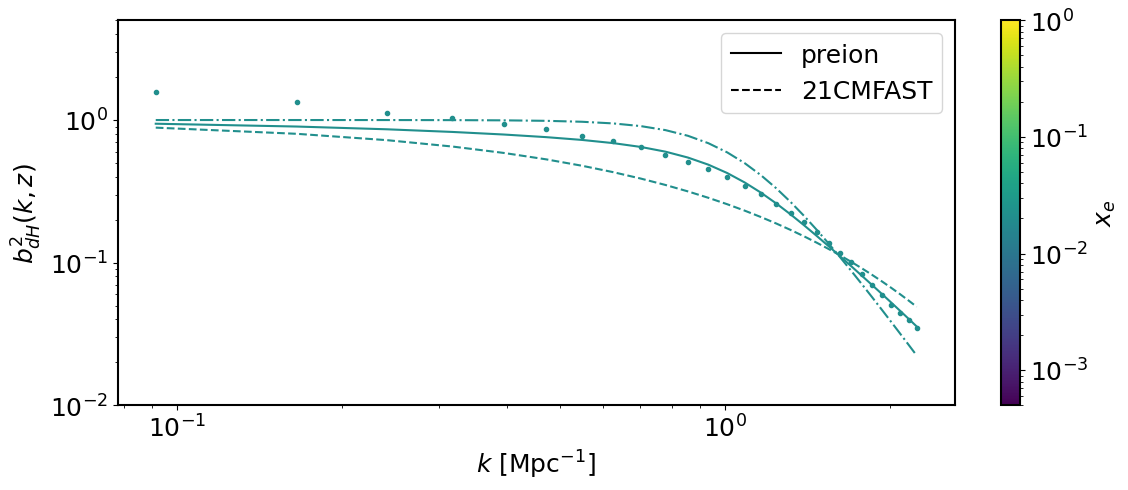

In [ ]:
# iz = 12

# # kf=.1
# # g=0.5
# # alpha=1.
# kf, g, alpha = res.x
# a = np.exp(-kb / kf)
# b = 1.0 / (1.0 + np.power(g * kb / kf, alpha))

# fig, ax = plt.subplots(figsize=(12, 5))
# ax.loglog(kb, pkbb[iz]/model.Pk(kb, z_nodes[iz]), color=cmap(norm(model.xe(z_nodes[iz])[0]/model.f)), marker='.', lw=0.)
# ax.loglog(kb, 0.5 * (a+b), color=cmap(norm(model.xe(z_nodes[iz])[0]/model.f)))
# ax.loglog(kb, a, color=cmap(norm(model.xe(z_nodes[iz])[0]/model.f)), ls='--')
# ax.loglog(kb, b, color=cmap(norm(model.xe(z_nodes[iz])[0]/model.f)), ls='-.')
# # ax.set_ylim(1e0, 1e7)
# ax.plot([], [], color='k', ls='-', label='preion')
# ax.plot([], [], color='k', ls='--', label='21CMFAST')
# ax.legend()
# ax.set_ylim(1e-2, 5)
# ax.set_xlabel(r'$k$ [Mpc$^{-1}]$')
# ax.set_ylabel(r'$b_{dH}^2(k, z)$')
# sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
# c_bar = plt.colorbar(sm, fraction=0.05, label=r'$x_e$', ax=ax)

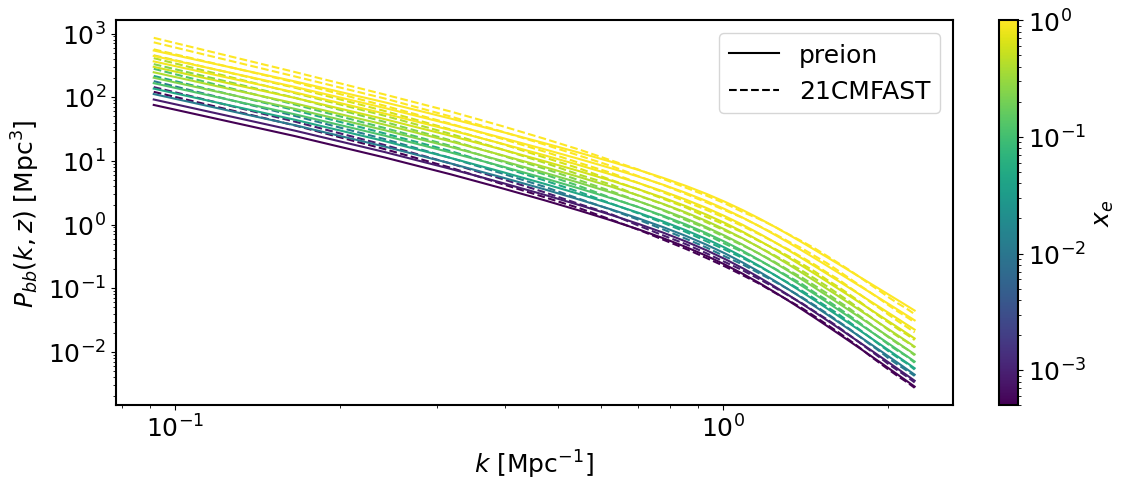

In [116]:
fig, ax = plt.subplots(figsize=(12, 5))
for iz in np.arange(0, z_nodes.size, 5):
    ax.loglog(kb, pkbb[iz], color=cmap(norm(model.xe(z_nodes[iz])[0]/model.f)), ls='--')
    ax.loglog(kb, model.bdH(kb) * model.Pk(kb, z_nodes[iz]), color=cmap(norm(model.xe(z_nodes[iz])[0]/model.f)))
# ax.set_ylim(1e0, 1e7)
ax.plot([], [], color='k', ls='-', label='preion')
ax.plot([], [], color='k', ls='--', label='21CMFAST')
ax.legend()
ax.set_xlabel(r'$k$ [Mpc$^{-1}]$')
ax.set_ylabel(r'$P_{bb}(k, z)$ [Mpc$^3]$')
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
c_bar = plt.colorbar(sm, fraction=0.05, label=r'$x_e$', ax=ax)

## 21cm power spectrum

In [26]:
pk21 = np.loadtxt('data_big_lightcone/big_lightcone_pk21.txt')
k21 = pk21[:, 0]
pk21 = np.delete(pk21, 0, axis=1).T * np.pi/k21

To compute the 21cm power spectrum, use the `get_p21(k,z)` method.

Text(0, 0.5, 'Reionisation history')

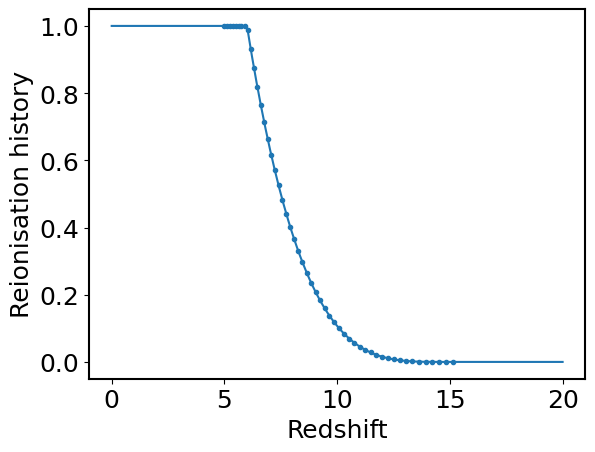

In [27]:
z = np.linspace(0, 20, 300)

plt.figure()
plt.plot(z, model.xe(z))
plt.scatter(z_nodes, model.xe(z_nodes), marker='.')
plt.xlabel(r'Redshift')
plt.ylabel(r'Reionisation history')

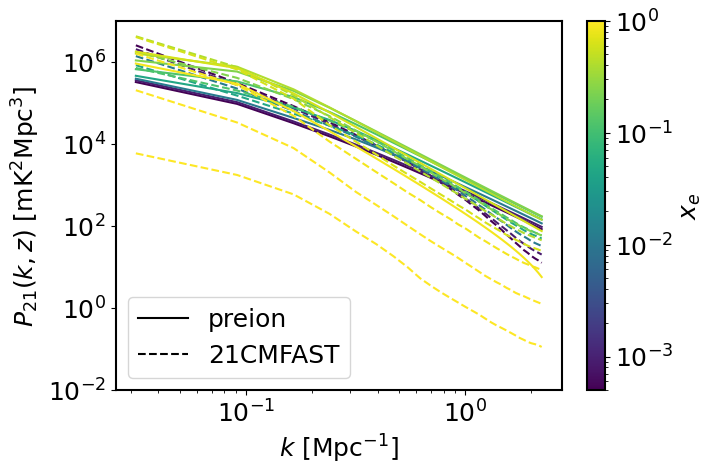

In [28]:
fig, ax = plt.subplots()
for iz in np.arange(0, z_nodes.size, 5):
    ax.loglog(k21, pk21[iz], color=cmap(norm(model.xe(z_nodes[iz])[0]/model.f)), ls='--')
    ax.loglog(k21, model.get_p21(k21, z_nodes[iz], mK=True, log=False, pk_units=True), color=cmap(norm(model.xe(z_nodes[iz])[0]/model.f)))
# ax.set_ylim(1e0, 1e7)
ax.plot([], [], color='k', ls='-', label='preion')
ax.plot([], [], color='k', ls='--', label='21CMFAST')
ax.legend()
ax.set_xlabel(r'$k$ [Mpc$^{-1}]$')
ax.set_ylabel(r'$P_{21}(k, z)$ [mK$^2$Mpc$^3]$')
ax.set_ylim(1e-2, 1e7)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
c_bar = plt.colorbar(sm, fraction=0.05, label=r'$x_e$', ax=ax)

In [26]:
# fig, ax = plt.subplots()
# for iz in np.arange(0, z_nodes.size, 5):
#     ax.loglog(k21, pk21[iz]*k21**2/2./np.pi, color=cmap(norm(model.xe(z_nodes[iz])[0]/model.f)), ls='--')
#     ax.loglog(k21, model.get_p21(k21, z_nodes[iz], mK=True, log=False, pk_units=False), color=cmap(norm(model.xe(z_nodes[iz])[0]/model.f)))
# # ax.set_ylim(1e0, 1e7)
# ax.plot([], [], color='k', ls='-', label='preion')
# ax.plot([], [], color='k', ls='--', label='21CMFAST')
# ax.legend()
# ax.set_xlabel(r'$k$ [Mpc$^{-1}]$')
# ax.set_ylabel(r'$\Delta^2_{21}(k, z)$ [mK$^2$]$')
# ax.set_ylim(2e-3, 2e2)
# sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
# c_bar = plt.colorbar(sm, fraction=0.05, label=r'$x_e$', ax=ax)

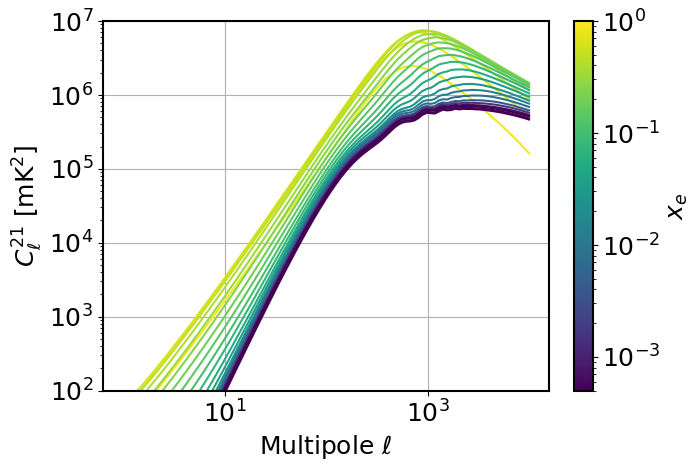

In [95]:
fig, ax = plt.subplots()
for iz, z in enumerate(zarr):
    ax.loglog(ells_plot, model.get_cl21(z, ells_plot, Dells=True, delta_nu=10.*units.MHz), color=cmap(norm(model.xe(z)[0]/model.f)))
ax.set_ylim(1e2, 1e7)
ax.grid()
ax.set_xlabel(r'Multipole $\ell$')
ax.set_ylabel(r'$C_\ell^{21}$ [mK$^2$]')
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
c_bar = plt.colorbar(sm, fraction=0.05, label=r'$x_e$', ax=ax)

## Analytical cross-spectrum

In [169]:
delta_nu = 100.
z21 = model.zre_h
print(z21)

7.5


In [170]:
Dl_tau_21 = model.get_tau_21_cross(z21, ells_plot, Dells=True, delta_nu=delta_nu)
print(Dl_tau_21.unit)

uK


In [171]:
cl21 = model.get_cl21(z21, ells_plot, Dells=True, delta_nu=0.*units.MHz)
print(cl21.unit)
tau_ps = model.get_tau(ells=ells_plot, signal='both', Dells=True)

uK2


In [172]:
l21, cl_tau21_from_sim, cl_tau21_from_sim_err = np.loadtxt(f'data_big_lightcone/big_lightcone_cltau21_z{z21:.1f}.txt', unpack=True)

Text(0.5, 1.0, '$\\Delta \\nu=100.0$MHz')

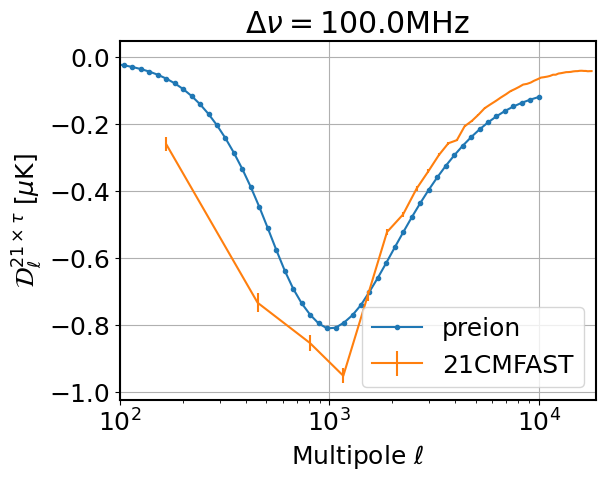

In [173]:
m = cl_tau21_from_sim != 0.

fig, ax = plt.subplots()
ax.plot(
    ells_plot, Dl_tau_21,
    marker='.', label='preion')
ax.errorbar(l21[m], l21[m] * (l21[m]+1.)/2./np.pi * cl_tau21_from_sim[m],
            yerr=l21[m] * (l21[m]+1.) * cl_tau21_from_sim_err/2./np.pi,
            label='21CMFAST')
plt.xlabel(r'Multipole $\ell$')
plt.ylabel(r'$\mathcal{D}_\ell^{21\times \tau}$ [$\mu$K]')
plt.legend()
plt.tight_layout()
# ax.legend(frameon=False, ncols=2)
ax.set_xlim(left=100)
ax.grid()
ax.set_xscale('log')
ax.set_title(rf'$\Delta \nu={delta_nu:.1f}$MHz')